In [5]:
import pandas as pd

df = pd.read_csv("mart.csv")
df.head()



,flight_date,airport_code,uni_dep_connections,uni_arr_connections,planned_flights,total_cancellations,total_diverted,occurred_flights,avg_unique_airplanes,avg_unique_airlines,min_temp_c,max_temp_c,precipitation_mm,max_snow_mm,avg_wind_direction,avg_wind_speed_kmh,wind_peakgust_kmh,city,country,name
0,2014-01-01,BWI,61,61,422,5,1,417,181.0,9.0,-4.9,6.7,0.0,0,NaN,5.8,NaN,Baltimore,United States,Baltimore/Washington International Thurgood Ma...
1,2014-01-02,BWI,61,61,512,62,3,450,208.5,9.0,-2.1,2.2,9.9,0,NaN,11.5,NaN,Baltimore,United States,Baltimore/Washington International Thurgood Ma...
2,2014-01-03,BWI,61,61,508,78,3,430,200.5,9.0,-12.7,-2.7,1.3,10,NaN,16.9,NaN,Baltimore,United States,Baltimore/Washington International Thurgood Ma...
3,2014-01-04,BWI,61,61,421,28,0,393,179.0,9.0,-14.3,0.0,0.0,8,NaN,4.3,NaN,Baltimore,United States,Baltimore/Washington International Thurgood Ma...
4,2014-01-05,BWI,61,61,466,44,4,422,187.0,9.0,-8.2,2.8,2.8,5,NaN,5.4,NaN,Baltimore,United States,Baltimore/Washington International Thurgood Ma...


In [6]:
import sys
sys.version


'3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]'

In [ ]:
import pandas as pd

df = pd.read_csv("mart.csv")

df["flight_date"] = pd.to_datetime(df["flight_date"])

df = df[df["planned_flights"] > 0].copy()

df["cancellation_rate"] = df["total_cancellations"] / df["planned_flights"]

df = df.sort_values(["airport_code", "flight_date"])

df.head()


,flight_date,airport_code,uni_dep_connections,uni_arr_connections,planned_flights,total_cancellations,total_diverted,occurred_flights,avg_unique_airplanes,avg_unique_airlines,...,max_temp_c,precipitation_mm,max_snow_mm,avg_wind_direction,avg_wind_speed_kmh,wind_peakgust_kmh,city,country,name,cancellation_rate
0,2014-01-01,BWI,61,61,422,5,1,417,181.0,9.0,...,6.7,0.0,0,NaN,5.8,NaN,Baltimore,United States,Baltimore/Washington International Thurgood Ma...,0.011848
1,2014-01-02,BWI,61,61,512,62,3,450,208.5,9.0,...,2.2,9.9,0,NaN,11.5,NaN,Baltimore,United States,Baltimore/Washington International Thurgood Ma...,0.121094
2,2014-01-03,BWI,61,61,508,78,3,430,200.5,9.0,...,-2.7,1.3,10,NaN,16.9,NaN,Baltimore,United States,Baltimore/Washington International Thurgood Ma...,0.153543
3,2014-01-04,BWI,61,61,421,28,0,393,179.0,9.0,...,0.0,0.0,8,NaN,4.3,NaN,Baltimore,United States,Baltimore/Washington International Thurgood Ma...,0.066508
4,2014-01-05,BWI,61,61,466,44,4,422,187.0,9.0,...,2.8,2.8,5,NaN,5.4,NaN,Baltimore,United States,Baltimore/Washington International Thurgood Ma...,0.094421


In [8]:
print("Airports:", df["airport_code"].unique())
print("Date range:", df["flight_date"].min(), "→", df["flight_date"].max())

df[["cancellation_rate", "avg_wind_speed_kmh"]].describe()


Airports: ['BWI' 'CLT' 'DCA' 'EWR' 'JFK' 'PHL']
Date range: 2014-01-01 00:00:00 → 2014-03-31 00:00:00


,cancellation_rate,avg_wind_speed_kmh
count,540.000000,540.000000
mean,0.063228,14.889074
std,0.125313,7.186326
min,0.000000,2.200000
25%,0.006639,9.400000
50%,0.016834,14.000000
75%,0.057825,19.100000
max,0.916542,45.400000


In [12]:
df["cancellation_rate_7d"] = (
    df
    .groupby("airport_code")["cancellation_rate"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

df.columns


Index(['flight_date', 'airport_code', 'uni_dep_connections',
       'uni_arr_connections', 'planned_flights', 'total_cancellations',
       'total_diverted', 'occurred_flights', 'avg_unique_airplanes',
       'avg_unique_airlines', 'min_temp_c', 'max_temp_c', 'precipitation_mm',
       'max_snow_mm', 'avg_wind_direction', 'avg_wind_speed_kmh',
       'wind_peakgust_kmh', 'city', 'country', 'name', 'cancellation_rate',
       'cancellation_rate_7d'],
      dtype='object')

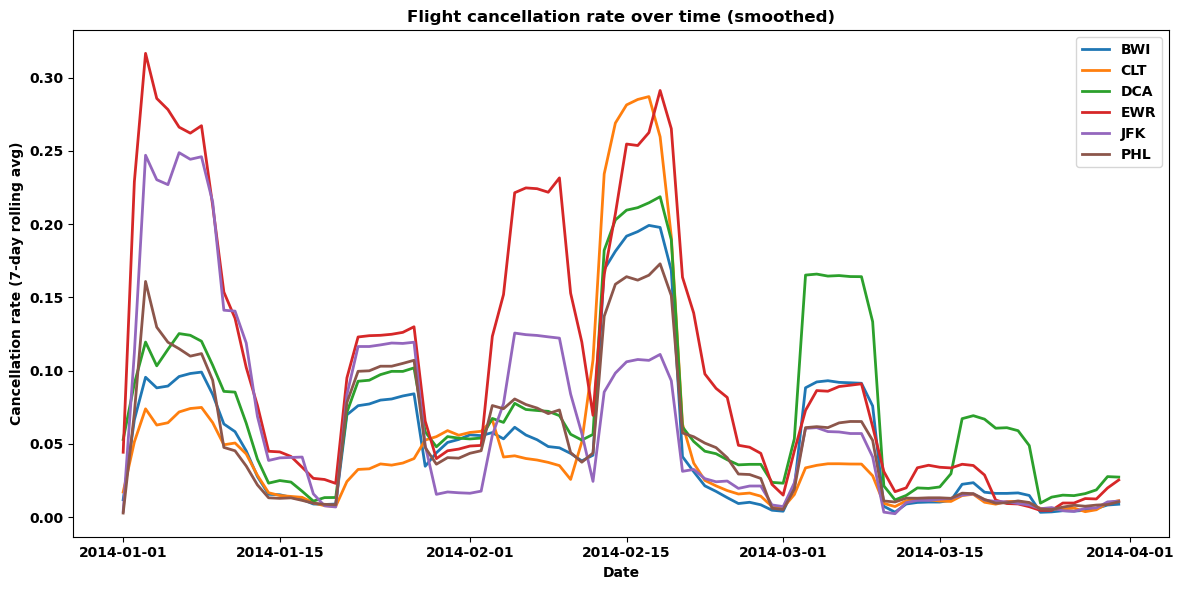

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for airport, g in df.groupby("airport_code"):
    plt.plot(
        g["flight_date"],
        g["cancellation_rate_7d"],
        label=airport,
        linewidth=2
    )

plt.xlabel("Date")
plt.ylabel("Cancellation rate (7-day rolling avg)")
plt.title("Flight cancellation rate over time (smoothed)")
plt.legend()
plt.tight_layout()
plt.show()


The chart shows the flight cancellation rate (7-day rolling average) for six U.S. airports from January to March 2014.

Key findings:

Clear spikes in flight cancellations are visible in early January and mid-February.
These peaks occur simultaneously across multiple airports, indicating a systemic external factor rather than isolated operational issues.

The strongest impact is observed at EWR (Newark) and JFK, where cancellation rates exceed 25–30% during peak periods.

BWI, CLT, DCA, and PHL also show increased cancellation rates, though with lower magnitude, likely reflecting regional differences in weather severity and airport operations.

Applying a 7-day rolling average reduces daily volatility and highlights periods of abnormal behavior, which align with known severe winter weather events such as snowstorms and extreme cold.

Conclusion:
Severe winter weather conditions have a significant and widespread impact on flight operations, leading to substantially higher cancellation rates, particularly at major airports in the northeastern United States.


In [14]:
df[["max_snow_mm", "cancellation_rate"]].describe()


,max_snow_mm,cancellation_rate
count,540.000000,540.000000
mean,3.738889,0.063228
std,7.798504,0.125313
min,0.000000,0.000000
25%,0.000000,0.006639
50%,0.000000,0.016834
75%,3.000000,0.057825
max,46.000000,0.916542


In [15]:
df_snow = df[df["max_snow_mm"] > 0].copy()

df_snow.shape


(152, 22)

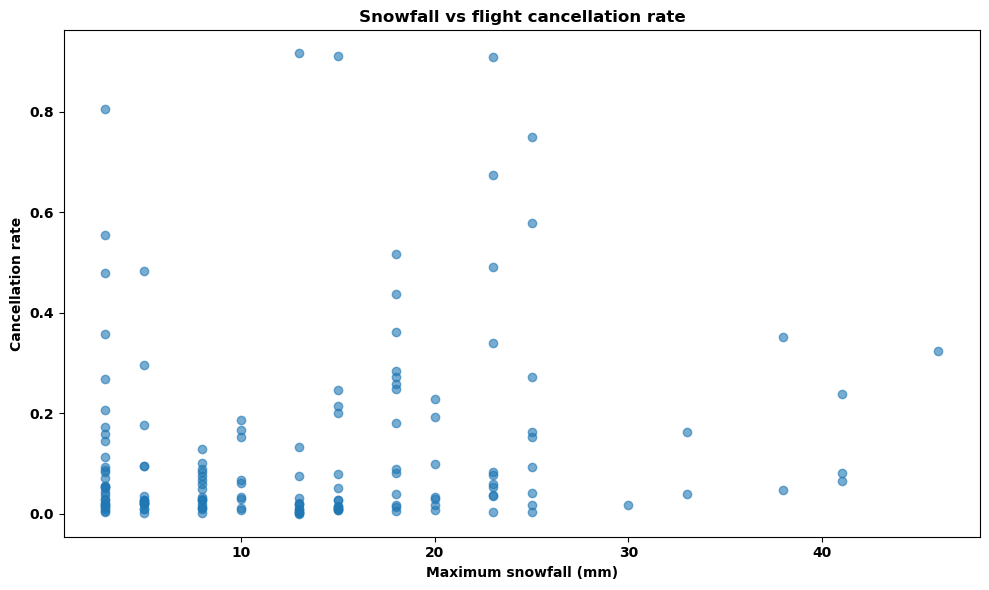

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df_snow["max_snow_mm"],
    df_snow["cancellation_rate"],
    alpha=0.6
)

plt.xlabel("Maximum snowfall (mm)")
plt.ylabel("Cancellation rate")
plt.title("Snowfall vs flight cancellation rate")

plt.tight_layout()
plt.show()


In [ ]:

bins = [0, 5, 10, 20, 30, 50]
labels = ["0–5", "5–10", "10–20", "20–30", "30+"]

df_snow["snow_bin"] = pd.cut(
    df_snow["max_snow_mm"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

snow_summary = (
    df_snow
    .groupby("snow_bin")["cancellation_rate"]
    .mean()
)

snow_summary


snow_bin
0–5      0.115674
5–10     0.059255
10–20    0.129805
20–30    0.231256
30+      0.163563
Name: cancellation_rate, dtype: float64

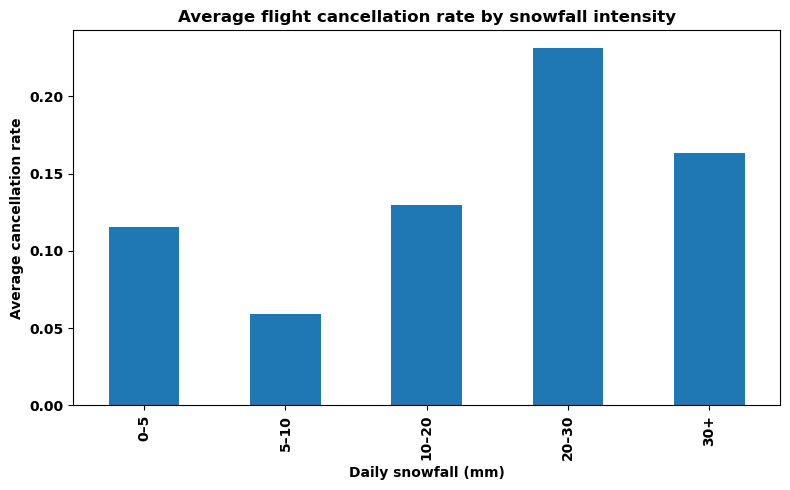

In [18]:
plt.figure(figsize=(8, 5))
snow_summary.plot(kind="bar")

plt.xlabel("Daily snowfall (mm)")
plt.ylabel("Average cancellation rate")
plt.title("Average flight cancellation rate by snowfall intensity")

plt.tight_layout()
plt.show()


Although the 30+ mm category represents the most extreme snowfall events, its average cancellation rate is lower than in the 20–30 mm range. This can be explained by a smaller number of observations and proactive operational decisions, such as preemptive flight cancellations or reduced scheduling. As a result, the impact of snowfall on cancellations follows a threshold-based rather than a linear pattern.